In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"filippogibertini","key":"2978b6ff757f99acc46ec6a80749c8db"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# !ls -lah ~ | grep kaggle

In [ ]:
!kaggle datasets download -d nikitricky/chess-positions

Dataset URL: https://www.kaggle.com/datasets/nikitricky/chess-positions
License(s): DbCL-1.0
  0% 0.00/18.4M [00:00<?, ?B/s]
100% 18.4M/18.4M [00:00<00:00, 1.66GB/s]


In [ ]:
!unzip chess-positions.zip -d /content/data

Archive:  chess-positions.zip
  inflating: /content/data/positions.csv  


In [ ]:
! rm -r /content/chess-positions.zip /content/kaggle.json

In [ ]:
import numpy as np
import pandas as pd
import sklearn
import torch

!pip install chess
import chess
import chess.polyglot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 64.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=07102e862eab252866fbd90fd86081e6aaa830e9e5c8cee96b3d835f14abfc31
  Stored in directory: /root/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess


In [ ]:
#Reading in our training data
df = pd.read_csv("/content/data/positions.csv")

/tmp/ipython-input-263116981.py:2: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/data/positions.csv")


In [ ]:
# just keep the fen position and the score
df.drop(columns=[c for c in df.columns if c not in ["fen", "score"]], inplace=True)
df.dropna(inplace=True) # if we don't have an evaluation we don't want that position

In [ ]:
# we split the dataset in features and labels
positions = np.asanyarray(df["fen"].tolist())
evaluations = np.asanyarray(df["score"].tolist())

In [ ]:
# take a look at tha data
print(positions[:10])
print(evaluations[:10])

['rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1'
 'rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2'
 'rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBNR b KQkq - 0 2'
 'rnbqkbnr/p1pp1ppp/1p2p3/8/3PP3/8/PPP2PPP/RNBQKBNR w KQkq - 0 3'
 'rnbqkbnr/p1pp1ppp/1p2p3/8/3PP3/P7/1PP2PPP/RNBQKBNR b KQkq - 0 3'
 'rn1qkbnr/pbpp1ppp/1p2p3/8/3PP3/P7/1PP2PPP/RNBQKBNR w KQkq - 1 4'
 'rn1qkbnr/pbpp1ppp/1p2p3/8/3PP3/P1N5/1PP2PPP/R1BQKBNR b KQkq - 2 4'
 'rn1qkb1r/pbpp1ppp/1p2p2n/8/3PP3/P1N5/1PP2PPP/R1BQKBNR w KQkq - 3 5'
 'rn1qkb1r/pbpp1ppp/1p2p2B/8/3PP3/P1N5/1PP2PPP/R2QKBNR b KQkq - 0 5'
 'rn1qkb1r/pbpp1p1p/1p2p2p/8/3PP3/P1N5/1PP2PPP/R2QKBNR w KQkq - 0 6']
[ -35.   36.  -27.   81.  -65.   67.  -60.  151. -120.  123.]


In [ ]:
# this function converts from Forsyth-Edwards chess notation to an array
def FENtoVEC (FEN):
    pieces = {"r":-5,"n":-3,"b":-3.2,"q":-9.5,"k":-100,"p":-1,"R":5,"N":3,"B":3.2,"Q":9.5,"K":100,"P":1}
    position = FEN.split()[0]
    turn = FEN.split()[1]
    ret = []
    for i in range(len(position)):
        if position[i] == "/":
            continue
        if position[i] in pieces:
            ret.append(pieces[position[i]])
        else:
          ret.extend([0] * int(position[i])) # if the current value is not a letter but a number we need to append that number of zeros to the vector

    # simplest way to encode who's turn it is
    if turn == "w":
        ret.extend([1.0,0.0])
    else:
        ret.extend([0.0,1.0])
    return ret

''' OSS: instead of representig the single cell as a one-hot encoded vector with 12 dimension (6 possible pieces x 2 colors) we assign to the cell the value of the piece itself: a rook is 5, a queen is 9 etc... and for the black pieces we just put a negative value, this is also reflected in the fact that we encode -1 as "black completely winning" and +1 as "white completely winning" '''

' OSS: instead of representig the single cell as a one-hot encoded vector with 12 dimension (6 possible pieces x 2 colors) we assign to the cell the value of the piece itself: a rook is 5, a queen is 9 etc... and for the black pieces we just put a negative value, this is also reflected in the fact that we encode -1 as "black completely winning" and +1 as "white completely winning" '

In [ ]:
# # This function maps values into -1,1 without clipping first
# def map_in_minus_1_plus_1(vec):
#   old_max = vec.max()
#   old_min = vec.min()
#   new_max = 1
#   new_min = -1
#   ret = []
#   for i in range(len(vec)):
#     ret.append(new_min + ((vec[i]-old_min)/(old_max-old_min))*(new_max-new_min))

In [ ]:
# convert the positions to numeric values
positions = np.asarray([FENtoVEC(position) for position in positions])
# normalize everything
positions = positions / 100.0 # 100 = king's value
evaluations = np.clip(evaluations, -1000, 1000) / 1000 # I clip and normalize wrt 1000 centipawns which is 10 point of material, this is because there isn't really a difference in being winning by 10 points or 30

In [ ]:
# take a look at tha data
print(positions[0])

[-0.05  -0.03  -0.032 -0.095 -1.    -0.032 -0.03  -0.05  -0.01  -0.01
 -0.01  -0.01  -0.01  -0.01  -0.01  -0.01   0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.01   0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.01   0.01
  0.01   0.01   0.     0.01   0.01   0.01   0.05   0.03   0.032  0.095
  1.     0.032  0.03   0.05   0.     0.01 ]


In [ ]:
print(evaluations[:10])

[-0.035  0.036 -0.027  0.081 -0.065  0.067 -0.06   0.151 -0.12   0.123]


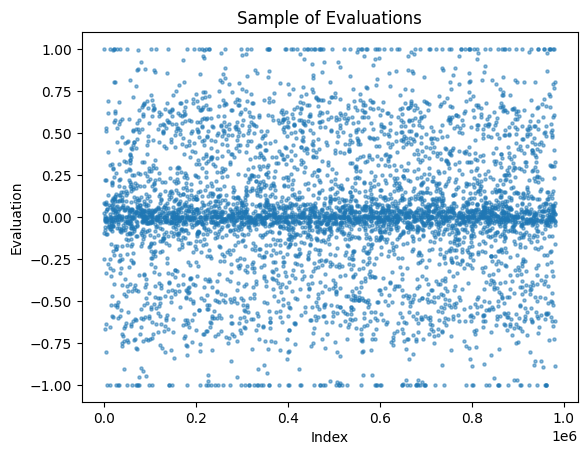

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

idx = np.random.choice(len(evaluations), size=5000, replace=False)
plt.scatter(idx, evaluations[idx], s=5, alpha=0.5)
plt.xlabel("Index")
plt.ylabel("Evaluation")
plt.title("Sample of Evaluations")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    positions, evaluations,
    test_size=0.25,       # 25%
    random_state=42,      # makes the split reproducible
    shuffle=True          # good default for random mixing
)

In [ ]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(736174, 66) (736174,)
(245392, 66) (245392,)


In [ ]:
# lets prepare our MLP
class MyModel(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = torch.nn.Linear(66, 66)
    self.relu1 = torch.nn.ReLU()
    self.fc2 = torch.nn.Linear(66, 128)
    self.relu2 = torch.nn.ReLU()
    self.fc3 = torch.nn.Linear(128, 128)
    self.relu3 = torch.nn.ReLU()
    self.fc4 = torch.nn.Linear(128, 66)
    self.relu4 = torch.nn.ReLU()
    self.out = torch.nn.Linear(66, 1)
    self.tanh = torch.nn.Tanh()

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu1(x)
    x = self.fc2(x)
    x = self.relu2(x)
    x = self.fc3(x)
    x = self.relu3(x)
    x = self.fc4(x)
    x = self.relu4(x)
    x = self.out(x)
    x = self.tanh(x)
    return x

In [ ]:
# lets use a dataloader to divide the train_x and train_y in batches
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
# lets define the training
model = MyModel()  # neural network class
criterion = torch.nn.MSELoss()  # Mean Squared Error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 20

In [ ]:
# # if we want we can upload weights from file
# # files.upload()
# model.load_state_dict(torch.load("model_weights.pth"))


In [ ]:
# lets define the training
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch_x, batch_y in train_dataloader:
        optimizer.zero_grad()
        outputs = model(batch_x.float())
        loss = criterion(outputs, batch_y.float().unsqueeze(1))
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}')
    # save weight to file every 20 epochs

torch.save(model.state_dict(), f"model_weights.pth")
# files.download(f"model_weights.pth")

Epoch 1/20, Loss: 0.1543
Epoch 2/20, Loss: 0.0838
Epoch 3/20, Loss: 0.0681
Epoch 4/20, Loss: 0.0641
Epoch 5/20, Loss: 0.0618
Epoch 6/20, Loss: 0.0603
Epoch 7/20, Loss: 0.0592
Epoch 8/20, Loss: 0.0584
Epoch 9/20, Loss: 0.0576
Epoch 10/20, Loss: 0.0571
Epoch 11/20, Loss: 0.0565
Epoch 12/20, Loss: 0.0562
Epoch 13/20, Loss: 0.0557
Epoch 14/20, Loss: 0.0553
Epoch 15/20, Loss: 0.0550
Epoch 16/20, Loss: 0.0547
Epoch 17/20, Loss: 0.0545
Epoch 18/20, Loss: 0.0542
Epoch 19/20, Loss: 0.0540
Epoch 20/20, Loss: 0.0538


In [ ]:
# lets evaluate our model
model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, labels in test_dataloader:
        outputs = model(inputs.float())
        loss = criterion(outputs, labels.unsqueeze(1).float())
        test_loss += loss.item() * inputs.size(0)
        # inputs.size(0) is the number of elements per batch
        # the MSE by default divides by the number of elements in batch so we multiply by it again in order to get back to the full loss

# since we have summed togheter the losses of every element in every batch we then divide by the number of elements total
test_loss /= len(test_dataset)
print(f'Test Loss (MSE): {test_loss:.4f}')

Test Loss (MSE): 0.0539


In [ ]:
''' The evaluation of our model shows a final test loss of ~0.05 and does not seem to be able to go lower
    this value is definitely too big to be acceptable: sqrt(0.05) = 0.224 which corresponds to 2.2 pawns.
    a +- 2.2 advantage in a chess game is the difference between being completely winning and completely lost.
'''

' The evaluation of our model shows a final test loss of ~0.05 and does not seem to be able to go lower\n    this value is definitely too big to be acceptable: sqrt(0.05) = 0.224 which corresponds to 2.2 pawns.\n    a +- 2.2 advantage in a chess game is the difference between being completely winning and completely lost.\n'

In [ ]:
# Let's test the model against itself

In [ ]:
import chess
import numpy as np
import torch # Assuming torch and the model are defined elsewhere as in the notebook

# --- Assume model, criterion, optimizer are defined and model loaded ---
# Example:
# model = MyModel()
# model.load_state_dict(torch.load("model_weights.pth"))
# model.eval() # Set model to evaluation mode

# --- Board representation and evaluation (keeping your corrected structure) ---

def board_to_vector(board):
    # Ensure King value matches training (100) and normalization is applied
    pieces = {"r":-5,"n":-3,"b":-3.2,"q":-9.5,"k":-100,"p":-1,
              "R":5,"N":3,"B":3.2,"Q":9.5,"K":100,"P":1, ".": 0}
    vector = np.zeros(64, dtype=np.float32)

    for i in range(64):
        piece = board.piece_at(i)
        if piece:
            vector[i] = pieces[piece.symbol()]

    if board.turn == chess.WHITE:
        turn_info = np.array([1.0, 0.0], dtype=np.float32)
    else:
        turn_info = np.array([0.0, 1.0], dtype=np.float32)

    # Normalize here before returning
    return np.concatenate((vector, turn_info)) / 100.0

def evaluate_board(board): # Pass board as argument
    if board.is_checkmate():
        # Evaluation relative to the player whose turn it WAS (since they got mated)
        # So if it's White's turn now, Black delivered mate. Return losing score.
        return -9999 if board.turn == chess.WHITE else 9999

    # Check for other draws BEFORE evaluating with NN
    if board.is_stalemate() or board.is_insufficient_material() or board.is_seventyfive_moves():
         return 0.0 # Standard draw score

    # --- Repetition Check ---
    # Check if the CURRENT position is already a draw by repetition
    # Note: can_claim_threefold_repetition() checks if the position *has occurred* 3 times
    # is_threefold_repetition() checks if it *has occurred* >= 3 times
    if board.can_claim_threefold_repetition():
        # Return a draw score, maybe slightly negative to discourage it passively
        # if other moves avoid it without being much worse.
        return 10000 # 0.1 # Or maybe -0.01 to slightly prefer avoiding draws

    # Use the neural network for evaluation
    with torch.no_grad():
        board_vec = board_to_vector(board) # Uses normalized vector now
        input_tensor = torch.tensor(board_vec, dtype=torch.float32).unsqueeze(0)
        output_tensor = model(input_tensor)
        evaluation = output_tensor.item() # Model output is already in [-1, 1]

        # Return evaluation relative to the current player
        return -evaluation if board.turn == chess.BLACK else evaluation

# --- Search Algorithms (Alpha-Beta and Quiescence) ---

# Keep track of positions encountered *during the current search path*
# Use Zobrist hashing for efficient position tracking
position_history = set()

def alphabeta(board, alpha, beta, depthleft): # Pass board as argument
    # --- Repetition check within search ---
    # Use Zobrist hash of the current board state
    board_hash = chess.polyglot.zobrist_hash(board)
    if board_hash in position_history:
        # We've reached this exact position before *in this specific search path*
        # value it zero to avoid draw by 3 repetition rule
        return 10000

    bestscore = -9999
    if depthleft == 0:
        # Pass board to quiesce
        return quiesce(board, alpha, beta)

    # Add current position hash to history for this path
    position_history.add(board_hash)

    # Generate legal moves for the current board state
    moves = list(board.legal_moves)
    # Consider adding move ordering here later (e.g., captures first) for better pruning

    for move in moves:
        board.push(move)
        # --- Check for draw by rule AFTER making the move ---
        if board.is_repetition(2): # Check if position occurred *twice before* (making this the 3rd)
             # If making this move results in threefold repetition, score it as a draw (or slight penalty)
             score = 10000 # 0.1 # or -0.01
        else:
            # Recursive call with the modified board state
             score = -alphabeta(board, -beta, -alpha, depthleft - 1)

        board.pop() # Undo the move

        if score >= beta:
            # Beta cutoff: This move is too good for the opponent, they wouldn't allow it.
            position_history.remove(board_hash) # Remove hash before returning
            return score # Return beta (or the actual score causing the cutoff)
        if score > bestscore:
            bestscore = score
        if score > alpha:
            # Alpha update: Found a better move for the current player
            alpha = score

    # Remove the hash from the history as we backtrack from this node
    # Check if it exists first in case we returned early due to beta cutoff
    if board_hash in position_history:
       position_history.remove(board_hash)

    return bestscore

def quiesce(board, alpha, beta): # Pass board as argument
    # Check for draws in the quiescence evaluation too
    if board.can_claim_threefold_repetition():
        return 10000 # 0.1

    stand_pat = evaluate_board(board) # Evaluate the current static position

    if stand_pat >= beta:
        return beta # Beta cutoff
    if alpha < stand_pat:
        alpha = stand_pat # Update alpha if static eval is better

    # Consider only capture moves (or potentially checks) for quiescence search
    for move in board.generate_legal_captures(): # More efficient than checking all legal moves
        board.push(move)
        # Check for draw AFTER the capture
        if board.is_repetition(2):
            score = 10000 # 0.1
        else:
            score = -quiesce(board, -beta, -alpha)
        board.pop()

        if score >= beta:
            return beta # Beta cutoff
        if score > alpha:
            alpha = score # Update alpha

    return alpha


def selectmove(board, depth): # Pass board as argument
    global position_history # Allow modification of the global history set
    bestMove = chess.Move.null()
    bestValue = -99999
    alpha = -100000
    beta = 100000

    moves = list(board.legal_moves)
    # Optional: Add simple move ordering (e.g., captures first)
    # moves.sort(key=lambda move: board.is_capture(move), reverse=True)

    for move in moves:
        board.push(move)
        # --- Clear history before starting search for a new move ---
        position_history.clear()
        position_history.add(chess.polyglot.zobrist_hash(board)) # Add starting position of search path

        # Check if the move immediately leads to repetition
        if board.is_repetition(2):
             boardValue = 10000 # 0.1 # Score as draw -> not very good
        else:
            # Start the search from the new positions
             boardValue = -alphabeta(board, -beta, -alpha, depth - 1)

        print(f"  Move {move}: evaluated as {boardValue}") # Debug print

        if boardValue > bestValue:
            bestValue = boardValue
            bestMove = move
        if boardValue > alpha:
            alpha = boardValue
        board.pop() # Undo the move

    print(f"Best move: {bestMove} with evaluation: {bestValue}")
    # Reset history just in case (should be empty if search completed fully)
    position_history.clear()
    return bestMove

In [ ]:
board = chess.Board() # Initialize board outside the loop

for i in range(20): # Or use while not board.is_game_over():
    print("\n" + "="*20)
    turn = "White" if board.turn == chess.WHITE else "Black"
    print(f"Move #{(i // 2) + 1} {turn}'s turn")
    print(board)

    if board.is_game_over():
        print("Game Over!")
        print("Result: " + board.result())
        break

    move = selectmove(board, 3) # Pass the current board state, use desired depth
    if move == chess.Move.null():
         print("Engine selected null move (shouldn't happen with legal moves available).")
         break

    board.push(move)

print("\nFinal Board Position:")
print(board)
print("Result:", board.result())


Move #1 White's turn
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R
  Move g1h3: evaluated as -10000
  Move g1f3: evaluated as -10000
  Move b1c3: evaluated as -10000
  Move b1a3: evaluated as -10000
  Move h2h3: evaluated as -10000
  Move g2g3: evaluated as -10000
  Move f2f3: evaluated as -10000
  Move e2e3: evaluated as -10000
  Move d2d3: evaluated as -10000
  Move c2c3: evaluated as -10000
  Move b2b3: evaluated as -10000
  Move a2a3: evaluated as -10000
  Move h2h4: evaluated as -10000
  Move g2g4: evaluated as -10000
  Move f2f4: evaluated as -10000
  Move e2e4: evaluated as -10000
  Move d2d4: evaluated as -10000
  Move c2c4: evaluated as -10000
  Move b2b4: evaluated as -10000
  Move a2a4: evaluated as -10000
Best move: g1h3 with evaluation: -10000

Move #1 Black's turn
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . N
P P P P P P P P
R N B Q K B . R
